# Forecast Intervals with Conformal Prediction

This notebook demonstrates how to add prediction intervals to Hyper-Tree forecasts using conformal prediction. The approach is model-agnostic and works with all Hyper-Tree models (AR, ETS, TreeNet-AR).

**How it works:** During training, a rolling-window cross-validation collects absolute residuals (conformity scores) per horizon step and per series. At forecast time, these scores are used to construct intervals at any requested confidence level.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from hypertrees.models import HyperTreeAR, HyperTreeETS, HyperTreeNetAR
from hypertrees import ForecastIntervals
import torch

## Load and Prepare Data

We use the Air Passengers dataset (monthly, 1949-1960) and reserve the last 12 months for testing.

In [2]:
df = pd.read_csv('https://datasets-nixtla.s3.amazonaws.com/air-passengers.csv', parse_dates=['ds'])
df.rename(columns={'unique_id': 'series_id', 'ds': 'date', 'y': 'value'}, inplace=True)
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter

fcst_h = 12
test = df.tail(fcst_h)
train = df.drop(test.index)

## General Parameters

In [3]:
freq = 'MS'
num_iterations = 100
ci_levels = [80, 90]
n_windows = 5
refit = False
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

ht_params = {
    'learning_rate': 1e-01,
}

## Hyper-Tree-AR with Forecast Intervals

Pass `forecast_intervals=ForecastIntervals(...)` to `train()` to calibrate conformal intervals, then request them via `level=[...]` in `forecast()`.

Key parameters of `ForecastIntervals`:
- **`n_windows`**: Number of rolling CV windows for calibration (more = better quantile resolution, but slower).
- **`method`**: `"conformal_distribution"` (default, can produce asymmetric bands) or `"conformal_error"` (symmetric).
- **`refit`**: If `True` (default), retrain the model for each CV window. If `False`, train once and reuse (faster).

In [4]:
lag_p = 12

ht_ar = HyperTreeAR(p=lag_p, freq=freq, fcst_h=fcst_h)
ht_ar.train(
    lgb_params=ht_params,
    num_iterations=num_iterations,
    train_data=train,
    seed=123,
    verbose=-1,
    forecast_intervals=ForecastIntervals(n_windows=n_windows, refit=refit)
)

ht_ar_fcst = ht_ar.forecast(test_data=test, level=ci_levels)
ht_ar_fcst.head()

,series_id,date,fcst,model,Hyper-Tree-AR(12)-lo-90,Hyper-Tree-AR(12)-lo-80,Hyper-Tree-AR(12)-hi-80,Hyper-Tree-AR(12)-hi-90
0,AirPassengers,1960-01-01,403.564685,Hyper-Tree-AR(12),374.900429,378.875007,428.254363,432.228941
1,AirPassengers,1960-02-01,402.666934,Hyper-Tree-AR(12),374.997106,377.199307,428.134560,430.336762
2,AirPassengers,1960-03-01,464.129094,Hyper-Tree-AR(12),436.837740,439.324120,488.934067,491.420447
3,AirPassengers,1960-04-01,453.348857,Hyper-Tree-AR(12),433.513237,434.107431,472.590283,473.184477
4,AirPassengers,1960-05-01,466.937533,Hyper-Tree-AR(12),451.324017,452.709793,481.165273,482.551049


## Hyper-Tree-ETS with Forecast Intervals

In [5]:
ht_ets = HyperTreeETS(
    ets_type="triple",
    seasonality_feature="month",
    season_length=12,
    freq=freq,
    fcst_h=fcst_h,
)
ht_ets.train(
    lgb_params=ht_params,
    num_iterations=num_iterations,
    train_data=train,
    seed=123,
    verbose=-1,
    forecast_intervals=ForecastIntervals(n_windows=n_windows, refit=refit),
)

ht_ets_fcst = ht_ets.forecast(test_data=test, level=ci_levels)
ht_ets_fcst.head()

,series_id,date,fcst,model,Hyper-Tree-ETS(triple)-lo-90,Hyper-Tree-ETS(triple)-lo-80,Hyper-Tree-ETS(triple)-hi-80,Hyper-Tree-ETS(triple)-hi-90
0,AirPassengers,1960-01-01,412.837921,Hyper-Tree-ETS(triple),402.068939,404.092072,421.583771,423.606903
1,AirPassengers,1960-02-01,388.689178,Hyper-Tree-ETS(triple),375.984319,376.072855,401.305502,401.394038
2,AirPassengers,1960-03-01,446.611877,Hyper-Tree-ETS(triple),427.777397,432.720078,460.503677,465.446358
3,AirPassengers,1960-04-01,428.627716,Hyper-Tree-ETS(triple),402.167624,404.361401,452.894031,455.087808
4,AirPassengers,1960-05-01,447.878479,Hyper-Tree-ETS(triple),412.318495,417.967679,477.789279,483.438463


## Hyper-TreeNet-AR with Forecast Intervals

In [6]:
import torch

network_params = {
    'learning_rate': 1e-3,
    'embedding_dimension': 1,
    'hidden_dim': 128,
    'dropout': 0.1,
    'use_random_projection': True,
    'rp_embed_dim': lag_p,
}

htnet_ar = HyperTreeNetAR(
    p=lag_p,
    freq=freq,
    fcst_h=fcst_h,
    device=device,
)
htnet_ar.train(
    lgb_params=ht_params,
    network_params=network_params,
    num_iterations=num_iterations,
    train_data=train,
    seed=123,
    verbose=-1,
    forecast_intervals=ForecastIntervals(n_windows=n_windows, refit=refit),
)

htnet_ar_fcst = htnet_ar.forecast(test_data=test, level=ci_levels)
htnet_ar_fcst.head()

,series_id,date,fcst,model,Hyper-TreeNet-AR(12)-lo-90,Hyper-TreeNet-AR(12)-lo-80,Hyper-TreeNet-AR(12)-hi-80,Hyper-TreeNet-AR(12)-hi-90
0,AirPassengers,1960-01-01,402.806098,Hyper-TreeNet-AR(12),374.728973,386.878973,418.733224,430.883224
1,AirPassengers,1960-02-01,398.804139,Hyper-TreeNet-AR(12),376.324306,385.665050,411.943227,421.283971
2,AirPassengers,1960-03-01,423.079688,Hyper-TreeNet-AR(12),382.422566,389.735466,456.423911,463.736811
3,AirPassengers,1960-04-01,429.395641,Hyper-TreeNet-AR(12),401.544587,410.783853,448.007429,457.246694
4,AirPassengers,1960-05-01,446.548640,Hyper-TreeNet-AR(12),418.092466,420.452339,472.644941,475.004814


## Plot Forecasts with Intervals

The `plot_example_forecast` helper automatically detects and shades interval columns present in the forecast DataFrame.

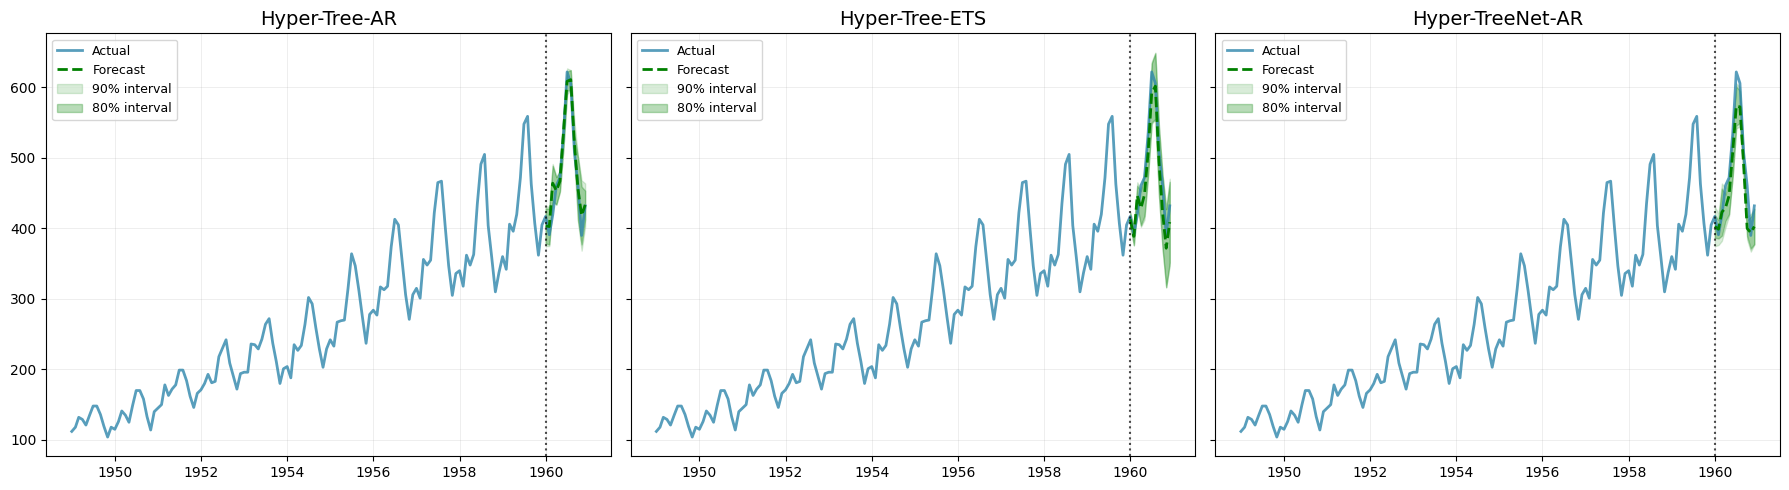

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (fcst_df, title) in zip(axes, [
    (ht_ar_fcst, "Hyper-Tree-AR"),
    (ht_ets_fcst, "Hyper-Tree-ETS"),
    (htnet_ar_fcst, "Hyper-TreeNet-AR"),
]):
    import re
    model_name = fcst_df["model"].iloc[0]

    ax.plot(df["date"], df["value"], label="Actual", color="#2E86AB", linewidth=2, alpha=0.8)
    ax.plot(fcst_df["date"], fcst_df["fcst"], label="Forecast", color="green", linestyle="--", linewidth=2)

    detected = sorted(
        int(m.group(1))
        for c in fcst_df.columns
        for m in [re.fullmatch(rf"{re.escape(model_name)}-lo-(\d+)", c)]
        if m
    )
    alphas = [0.15, 0.28, 0.40]
    shade = {lv: a for lv, a in zip(sorted(detected, reverse=True), alphas)}
    for lv in sorted(detected, reverse=True):
        ax.fill_between(
            fcst_df["date"],
            fcst_df[f"{model_name}-lo-{lv}"],
            fcst_df[f"{model_name}-hi-{lv}"],
            color="green", alpha=shade.get(lv, 0.2), label=f"{lv}% interval",
        )

    ax.axvline(x=fcst_df["date"].min(), color="black", linestyle=":", alpha=0.7)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparing Methods: `conformal_distribution` vs `conformal_error`

The default `conformal_distribution` builds synthetic forecast paths and can produce asymmetric intervals. The alternative `conformal_error` takes quantiles of absolute errors directly, always producing symmetric bands.

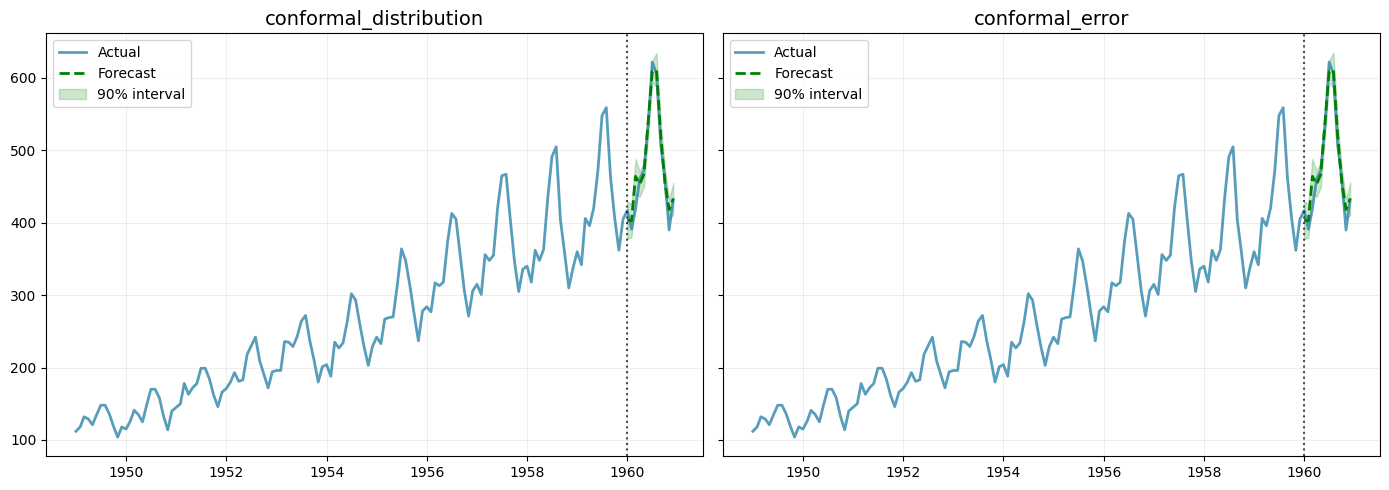

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, method in zip(axes, ["conformal_distribution", "conformal_error"]):
    model = HyperTreeAR(p=lag_p, freq=freq, fcst_h=fcst_h)
    model.train(
        lgb_params=ht_params,
        num_iterations=num_iterations,
        train_data=train,
        seed=123,
        verbose=-1,
        forecast_intervals=ForecastIntervals(n_windows=5, method=method),
    )
    fcst = model.forecast(test_data=test, level=[90])
    model_name = fcst["model"].iloc[0]

    ax.plot(df["date"], df["value"], label="Actual", color="#2E86AB", linewidth=2, alpha=0.8)
    ax.plot(fcst["date"], fcst["fcst"], label="Forecast", color="green", linestyle="--", linewidth=2)
    ax.fill_between(
        fcst["date"],
        fcst[f"{model_name}-lo-90"],
        fcst[f"{model_name}-hi-90"],
        color="green", alpha=0.2, label="90% interval",
    )
    ax.axvline(x=fcst["date"].min(), color="black", linestyle=":", alpha=0.7)
    ax.set_title(method, fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()